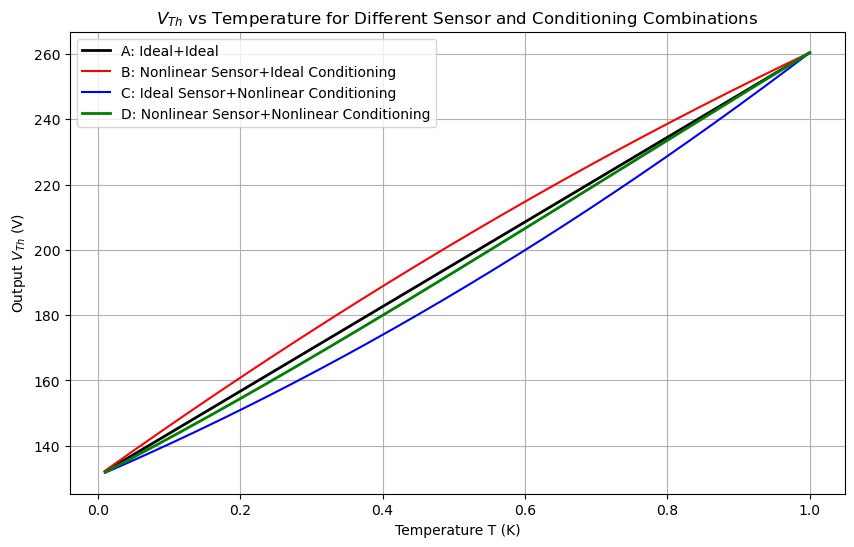

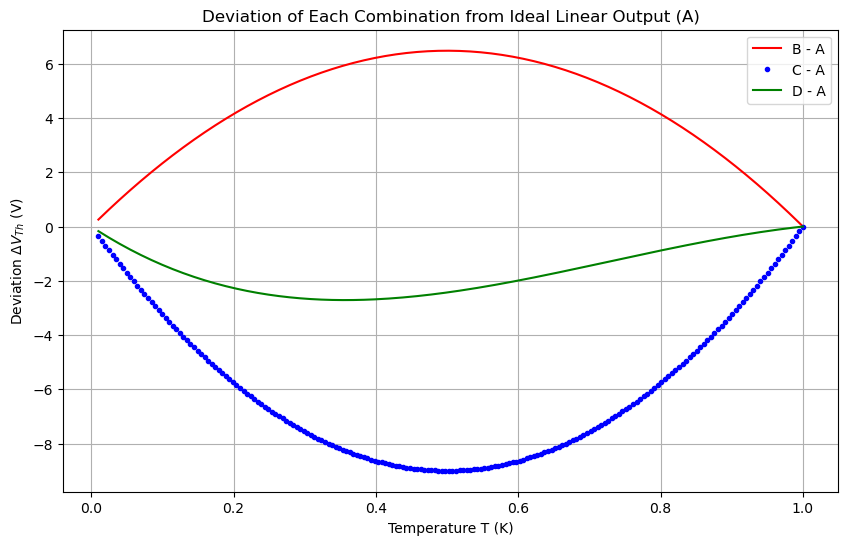

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 常数
R0 = 100.0          # Ω
VTh0 = 1.2          # V

# 温度范围 (0.01 到 1 K)
T = np.linspace(0.01, 1, 200)

# 1. 理想传感元件 + 理想信号调理 (A)
R_ideal = R0 * (1 + T)
V_A = VTh0 * (1 + 1.08 * R_ideal)

# 2. 非线性传感元件 + 理想信号调理 (B)
R_nonlin = R0 * (1 + T - 0.2 * T * (T - 1))
V_B = VTh0 * (1 + 1.08 * R_nonlin)   # 信号调理理想

# 3. 理想传感元件 + 非线性信号调理 (C)
R_ideal_C = R0 * (1 + T)   # 同 A
# 非线性调理公式中的 (R - R0)(R - 2R0) 项
term_C = 0.003 * (R_ideal_C - R0) * (R_ideal_C - 2 * R0)
V_C = VTh0 * (1 + 1.08 * R_ideal_C + term_C)

# 4. 非线性传感元件 + 非线性信号调理 (D)
R_nonlin_D = R_nonlin       # 同 B
term_D = 0.003 * (R_nonlin_D - R0) * (R_nonlin_D - 2 * R0)
V_D = VTh0 * (1 + 1.08 * R_nonlin_D + term_D)

# 绘制 V_Th vs T 曲线
plt.figure(figsize=(10, 6))
plt.plot(T, V_A, 'k', label='A: Ideal+Ideal', linewidth=2)
plt.plot(T, V_B, 'r', label='B: Nonlinear Sensor+Ideal Conditioning')
plt.plot(T, V_C, 'b', label='C: Ideal Sensor+Nonlinear Conditioning')
plt.plot(T, V_D, 'g', label='D: Nonlinear Sensor+Nonlinear Conditioning', linewidth=2)
plt.xlabel('Temperature T (K)')
plt.ylabel('Output $V_{Th}$ (V)')
plt.title('$V_{Th}$ vs Temperature for Different Sensor and Conditioning Combinations')
plt.legend()
plt.grid(True)
plt.show()

# 绘制与理想情况 A 的偏差
plt.figure(figsize=(10, 6))
plt.plot(T, V_B - V_A, 'r', label='B - A')
plt.plot(T, V_C - V_A, 'b.', label='C - A')
plt.plot(T, V_D - V_A, 'g', label='D - A')
plt.xlabel('Temperature T (K)')
plt.ylabel('Deviation Δ$V_{Th}$ (V)')
plt.title('Deviation of Each Combination from Ideal Linear Output (A)')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
from sympy import symbols, cos, sin, sqrt, Matrix, simplify, atan, diff, atan2

# A,B,C,D 四种组合的输出电压表达式
R = symbols('R')
T = symbols('T')
V_A_expr = VTh0 * (1 + 1.08 * R0 * (1 + T))
V_B_expr = VTh0 * (1 + 1.08 * R0 * (1 + T - 0.2 * T * (T - 1)))
R_ideal_C = R0 * (1 + T)
term_C = 0.003 * (R_ideal_C - R0) * (R_ideal_C - 2 * R0)
V_C_expr = VTh0 * ( 1 + 1.08 * R_ideal_C + term_C)
R_nonlin_D = R0 * (1 + T - 0.2 * T * (T - 1))
term_D = 0.003 * (R_nonlin_D - R0) * (R_nonlin_D - 2 * R0)
V_D_expr = VTh0 * ( 1 + 1.08 * R_nonlin_D + term_D)
V_A = simplify(V_A_expr)
V_B = simplify(V_B_expr)
V_C = simplify(V_C_expr)
V_D = simplify(V_D_expr)
display(V_A, V_B, V_C, V_D)

129.6*T + 130.8

-25.92*T**2 + 155.52*T + 130.8

36.0*T**2 + 93.6*T + 130.8

1.44*T**4 - 17.28*T**3 + 33.12*T**2 + 112.32*T + 130.8